Note on Preprocessing and Data Integrity

During the data preprocessing phase, a normalization step was applied to the numerical variables. Specifically, any value that exceeded ±3 standard deviations from the mean was automatically replaced with the median of the respective variable.

This transformation was implemented with future machine learning applications in mind, aiming to mitigate the influence of extreme outliers.

However, this adjustment directly affects the outcomes of the subsequent SQL queries and visual analyses.

Therefore, the current analysis should be considered for demonstration purposes only.

For accurate statistical inference or business insights, the original untransformed values should be restored prior to analysis.

Connecting with database

In [2]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd

# loading environment variables
load_dotenv()

DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")

# create engine for PostgreSQL database
db_url = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(db_url)




Performing a series of queries to get insights from the data

1) Count of Cars Per Brand and Model, Ordered by Vehicle Brand

In [3]:
query = text("""
    SELECT "Vehicle_brand", "Vehicle_model", COUNT(*) as total_cars_per_brand
    FROM cars
    GROUP BY "Vehicle_brand", "Vehicle_model"
    ORDER BY "Vehicle_brand" ASC
""")

with engine.connect() as connection:
    result = pd.read_sql_query(query, connection)

print(result)


     Vehicle_brand Vehicle_model  total_cars_per_brand
0           Abarth           595                    19
1           Abarth         Other                     2
2           Abarth           500                    10
3           Abarth           124                     2
4           Abarth  Grande Punto                     6
...            ...           ...                   ...
1289     Zaporożec         Other                     1
1290       Zastava         Other                     1
1291       Zastava           750                     1
1292       Zastava          1100                     3
1293           Żuk         Other                     5

[1294 rows x 3 columns]


2) Calculate the average price for each car brand, ordered from most to least expensive 

In [4]:

query = text("""
    SELECT "Vehicle_brand", ROUND(AVG("Price"), 2) AS average_price
    FROM cars
    GROUP BY "Vehicle_brand"
    ORDER BY average_price DESC
""")
with engine.connect() as connection:
    result = pd.read_sql_query(query, connection)


print(result)

    Vehicle_brand  average_price
0           Cupra       42050.13
1             MAN       41586.00
2           Tesla       35317.89
3      Vanderhall       34477.00
4        Maserati       27971.46
..            ...            ...
101      Vauxhall        2047.00
102         Rover        1915.20
103        Grecav        1725.00
104        Tavria        1483.50
105        Daewoo        1129.12

[106 rows x 2 columns]


3) Retrieve the 10 used cars with the highest prices.

In [5]:
query = text("""
    SELECT * FROM cars
    ORDER BY "Price" DESC
    LIMIT 10
""")

with engine.connect() as connection:
    result = pd.read_sql_query(query, connection)

print(result)


   Price  Production_year  Mileage_km  Power_HP  Displacement_cm3 Fuel_type  \
0  59800             2018     38222.0     265.0            2993.0    Diesel   
1  59800             2019      7400.0     135.0            1799.0  Gasoline   
2  59800             2019     14000.0     135.0            3490.0  Gasoline   
3  59800             2011    120000.0     135.0            1799.0  Gasoline   
4  59800             2016    119800.0     135.0            1799.0  Gasoline   
5  59800             2017     25000.0     135.0            1799.0  Gasoline   
6  59800             2019     10000.0     239.0            1950.0    Diesel   
7  59800             2020      2936.0     197.0            1991.0  Gasoline   
8  59800             2009    171000.0     135.0            1799.0  Gasoline   
9  59800             2015     65805.0     340.0            1799.0    Diesel   

                          Drive Transmission         Type  Doors_number  \
0                   Rear wheels    Automatic        sed

4) For each car brand, find the most frequently used fuel type

In [7]:
query = text("""
    SELECT "Vehicle_brand", "Fuel_type", "total_models_per_fuelType"
    FROM (
        SELECT "Vehicle_brand", "Fuel_type", COUNT("Fuel_type") AS "total_models_per_fuelType",
               ROW_NUMBER() OVER (PARTITION BY "Vehicle_brand" ORDER BY COUNT("Fuel_type") DESC) AS "rn"
        FROM "cars"
        GROUP BY "Vehicle_brand", "Fuel_type"
    ) AS "tbl"
    WHERE "rn" = 1;
""")

with engine.connect() as connection:
    result = pd.read_sql_query(query, connection)

print(result)


    Vehicle_brand Fuel_type  total_models_per_fuelType
0          Abarth  Gasoline                         39
1           Acura  Gasoline                         12
2           Aixam    Diesel                        101
3      Alfa Romeo    Diesel                        507
4          Alpine  Gasoline                          3
..            ...       ...                        ...
101      Wartburg  Gasoline                          8
102         Wołga  Gasoline                         10
103     Zaporożec   Ethanol                          1
104       Zastava  Gasoline                          5
105           Żuk  Gasoline                          5

[106 rows x 3 columns]


5) Retrieve all cars that:

Have mileage lower than the overall average mileage.

Have engine displacement higher than the overall average displacement.

Run on either Diesel or Gasoline fuel.

In [8]:
query = text("""
    WITH cars_filtering AS (
        SELECT * 
        FROM cars
        WHERE "Mileage_km" < (SELECT AVG("Mileage_km") FROM cars)
          AND "Displacement_cm3" > (SELECT AVG("Displacement_cm3") FROM cars)
          AND "Fuel_type" IN ('Diesel', 'Gasoline')
    )
    SELECT * 
    FROM cars_filtering
    ORDER BY "Vehicle_brand" ASC;
""")

with engine.connect() as connection:
    result = pd.read_sql_query(query, connection)

print(result)


       Price  Production_year  Mileage_km  Power_HP  Displacement_cm3  \
0      28750             2014    118000.0     300.0            3500.0   
1      13777             2010    110000.0     315.0            3664.0   
2      13777             2012    154000.0     300.0            3664.0   
3      10557             2012    150000.0     201.0            2354.0   
4       8487             2007    152000.0     300.0            3664.0   
...      ...              ...         ...       ...               ...   
29078   4577             2011     98600.0     100.0            2445.0   
29079   2737             2011     20056.0      70.0            2120.0   
29080   2507             2011     63518.0      70.0            2120.0   
29081   1311             2011    100000.0      36.0            2200.0   
29082   1587             2011     11880.0      60.0            2120.0   

      Fuel_type                         Drive Transmission           Type  \
0      Gasoline  4x4 (attached automatically) 

6) Retrieve all cars from the cars table that meet the following criteria:

Price greater than the average: The price of the car is greater than the average price of all the cars in the table. This is determined using a subquery that calculates the average price.

Offer publication date in 2021: The car's offer publication date (Offer_publication_date) must be within the year 2021. This is specified using the BETWEEN operator, with the dates '2021-01-01' and '2021-12-31'.

Car type is either Sedan or SUV: The car type (Type) must be either 'sedan' or 'SUV', specified by the IN operator.

The results are ordered alphabetically by Vehicle_brand.

In [9]:
query = text("""
    SELECT * 
    FROM cars
    WHERE "Price" > (SELECT AVG("Price") FROM cars)
      AND "Offer_publication_date" BETWEEN '2021-01-01' AND '2021-12-31'
      AND "Type" IN ('sedan', 'SUV')
    ORDER BY "Vehicle_brand";
""")

with engine.connect() as connection:
    result = pd.read_sql_query(query, connection)

print(result)


       Price  Production_year  Mileage_km  Power_HP  Displacement_cm3  \
0      16330             2015     65200.0     273.0            3471.0   
1      10557             2012    150000.0     201.0            2354.0   
2      11960             2009    298000.0     300.0            3664.0   
3      13777             2012    154000.0     300.0            3664.0   
4      20930             2014    110000.0     300.0            3664.0   
...      ...              ...         ...       ...               ...   
29620  14375             2011      1000.0      60.0            2120.0   
29621  12500             2011     96000.0      38.0             900.0   
29622  11730             2011       748.0      75.0            2445.0   
29623  22540             2011     33232.0      75.0            2445.0   
29624  20010             2011        50.0      75.0            2400.0   

            Fuel_type                         Drive Transmission   Type  \
0      Gasoline + LPG  4x4 (attached automatical

7) Retrieve all cars that:

Have a price higher than the average price for the same vehicle brand and model,

Were listed for sale in the year 2021 (from January 1st to December 31st),

And belong to either the 'sedan' or 'SUV' category.

This is a complex query and needs a special strategy (using explain plan and indexing)

Explain plan

In [10]:
query = text("""
    EXPLAIN ANALYZE
    SELECT *
    FROM cars AS c
    WHERE "Price" > (
            SELECT AVG("Price")
            FROM cars AS sub
            WHERE sub."Vehicle_brand" = c."Vehicle_brand"
              AND sub."Vehicle_model" = c."Vehicle_model"
        )
      AND "Offer_publication_date" BETWEEN '2021-01-01' AND '2021-12-31'
      AND "Type" IN ('sedan', 'SUV')
    LIMIT 1000;
""")


with engine.connect() as connection:
    result = pd.read_sql_query(query, connection)


print(result)

                                           QUERY PLAN
0   Limit  (cost=0.00..51739226.81 rows=1000 width...
1     ->  Seq Scan on cars c  (cost=0.00..95443351...
2           Filter: (("Offer_publication_date" >= ...
3                        Rows Removed by Filter: 5985
4                                           SubPlan 1
5             ->  Aggregate  (cost=5769.43..5769.4...
6                   ->  Seq Scan on cars sub  (cos...
7                         Filter: (("Vehicle_brand...
8                         Rows Removed by Filter: ...
9                             Planning Time: 0.225 ms
10                       Execution Time: 65380.577 ms


Create indexing to increase the performance of the query

In [11]:
create_indexes_query = """
    CREATE INDEX IF NOT EXISTS idx_cars_price ON cars("Price");
    CREATE INDEX IF NOT EXISTS idx_cars_offer_date ON cars("Offer_publication_date");
    CREATE INDEX IF NOT EXISTS idx_cars_type ON cars("Type");
    CREATE INDEX IF NOT EXISTS idx_cars_vehicle_brand ON cars("Vehicle_brand");
    CREATE INDEX IF NOT EXISTS idx_cars_vehicle_model ON cars("Vehicle_model");
"""


with engine.connect() as connection:
    connection.execute(text(create_indexes_query))

print("Indexes created successfully.")

Indexes created successfully.


Run the query

In [12]:
query = text("""
    WITH avg_prices AS (
        SELECT "Vehicle_brand", "Vehicle_model", AVG("Price") AS avg_price
        FROM cars
        GROUP BY "Vehicle_brand", "Vehicle_model"
    )
    SELECT *
    FROM cars AS c
    JOIN avg_prices AS a
        ON c."Vehicle_brand" = a."Vehicle_brand"
        AND c."Vehicle_model" = a."Vehicle_model"
    WHERE c."Price" > a.avg_price
      AND c."Offer_publication_date" BETWEEN '2021-01-01' AND '2021-12-31'
      AND c."Type" IN ('sedan', 'SUV');
""")


with engine.connect() as connection:
    result = pd.read_sql_query(query, connection)


print(result)

       Price  Production_year  Mileage_km  Power_HP  Displacement_cm3  \
0      20447             2019     31470.0      98.0            1798.0   
1      19803             2008    217600.0     173.0            2982.0   
2       5968             2011    318040.0     149.0            1984.0   
3      32661             2017     43328.0     352.0            1799.0   
4      24046             2016    149000.0     231.0            1995.0   
...      ...              ...         ...       ...               ...   
23695  17917             2017     58900.0     150.0            1998.0   
23696  54027             2020     42900.0     190.0            1995.0   
23697  22080             2015     50000.0     245.0            1997.0   
23698  36777             2018     46000.0     340.0            2998.0   
23699  25760             2013    188000.0     135.0            2993.0   

            Fuel_type                         Drive Transmission   Type  \
0              Hybrid                  Front whe

Drop indexes

In [13]:
query = text("""
    DROP INDEX IF EXISTS idx_cars_price;
    DROP INDEX IF EXISTS idx_cars_offer_date;
    DROP INDEX IF EXISTS idx_cars_type;
    DROP INDEX IF EXISTS idx_cars_vehicle_brand;
    DROP INDEX IF EXISTS idx_cars_vehicle_model;
""")


with engine.connect() as connection:
    connection.execute(query)

print("Indexes deleted successfully.")

Indexes deleted successfully.


Creating Visualizations to explore insights in the dataset. We will focus on the Mercedes-Benz models for demonstration purposes

Loading dataset with pandas

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv(r'C:\Users\kpapa\cars_etl_project\data\Car_sale_ads_clean.csv')


In [8]:
df.columns

Index(['Price', 'Production_year', 'Mileage_km', 'Power_HP',
       'Displacement_cm3', 'Fuel_type', 'Drive', 'Transmission', 'Type',
       'Doors_number', 'Colour', 'Vehicle_brand', 'Vehicle_model',
       'Offer_publication_date', 'Currency'],
      dtype='object')

Filtering all the cars of the dataset where the vehicle brand is Mercede-Benz

In [6]:
Mercedes = df[df["Vehicle_brand"] == "Mercedes-Benz"]
Mercedes.shape



(10046, 15)

In [7]:
Mercedes.head(3)

,Price,Production_year,Mileage_km,Power_HP,Displacement_cm3,Fuel_type,Drive,Transmission,Type,Doors_number,Colour,Vehicle_brand,Vehicle_model,Offer_publication_date,Currency
38,11385,2013,190000.0,265.0,2987.0,Diesel,4x4 (permanent),Automatic,station_wagon,5.0,silver,Mercedes-Benz,CLS,2021-08-04,PLN
59,4830,1994,309000.0,150.0,2199.0,Gasoline,Rear wheels,Manual,coupe,5.0,silver,Mercedes-Benz,Klasa E,2021-06-04,PLN
69,11500,2007,202808.0,306.0,1799.0,Gasoline + LPG,4x4 (permanent),Automatic,SUV,5.0,black,Mercedes-Benz,Klasa R,2021-05-05,PLN


1) Creating a barplot with the percentage distribution of all the Mercedes-Benz models

C:\Users\kpapa\AppData\Local\Temp\ipykernel_19976\535919441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_percentages.index, y=model_percentages.values, palette="coolwarm")


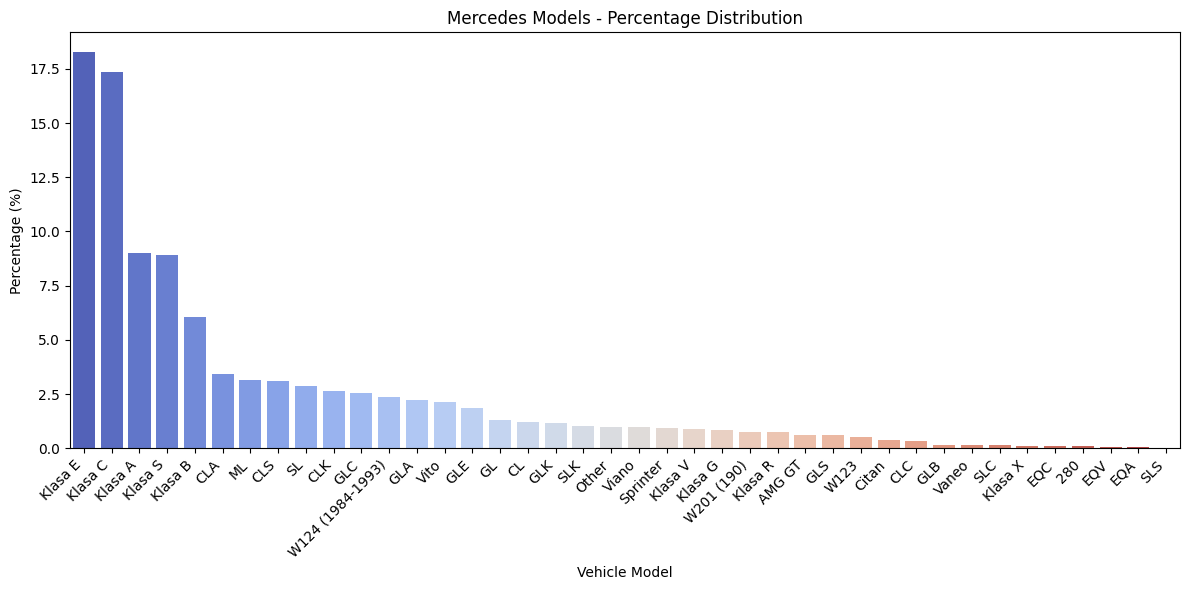

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

model_percentages = Mercedes['Vehicle_model'].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=model_percentages.index, y=model_percentages.values, palette="coolwarm")

plt.title('Mercedes Models - Percentage Distribution')
plt.xlabel('Vehicle Model')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


2) Creating a barplot containing the Average Mileage (km) per Fuel Type and Transmission for Mercedes-Benz cars

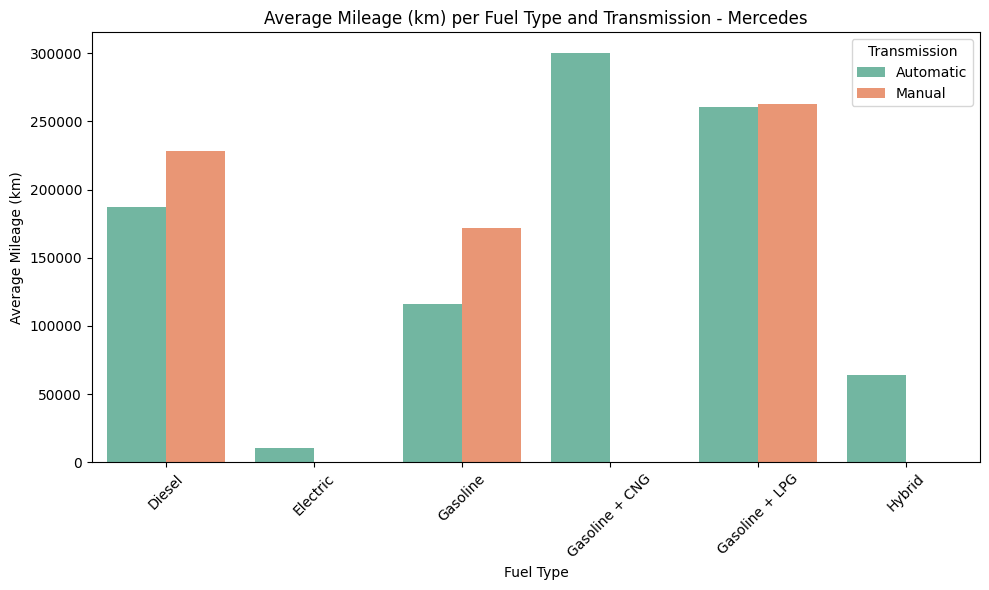

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Group by 'Fuel_type' and 'Transmission' and calculate the mean of 'Mileage_km'
grouped = Mercedes.groupby(['Fuel_type', 'Transmission'])['Mileage_km'].mean().reset_index()


plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x='Fuel_type', y='Mileage_km', hue='Transmission', palette='Set2')

plt.title('Average Mileage (km) per Fuel Type and Transmission - Mercedes')
plt.ylabel('Average Mileage (km)')
plt.xlabel('Fuel Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


3) Creating a barplot containing the Average Price per Model and Fuel Type for Mercedes-Benz cars

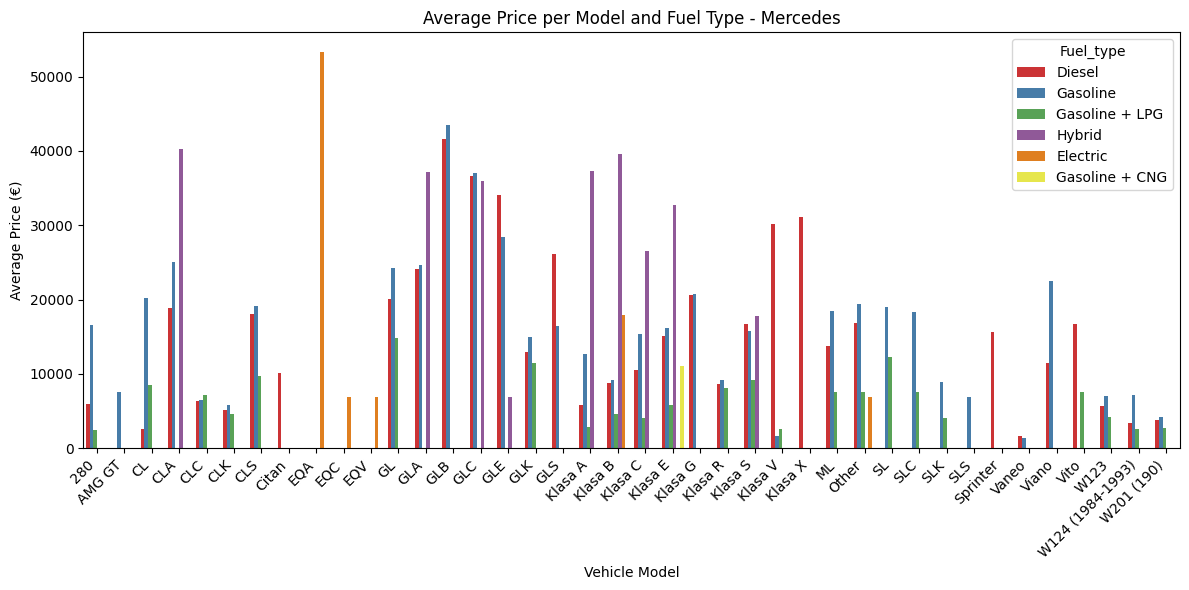

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Vehicle_model και Fuel_type
grouped_price = Mercedes.groupby(['Vehicle_model', 'Fuel_type'])['Price'].mean().reset_index()

# Bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=grouped_price, x='Vehicle_model', y='Price', hue='Fuel_type', palette='Set1')

plt.title('Average Price per Model and Fuel Type - Mercedes')
plt.ylabel('Average Price (€)')
plt.xlabel('Vehicle Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


3) Depictioning the Mercedes Sales Amount per Day for the year 2021

C:\Users\kpapa\AppData\Local\Temp\ipykernel_16580\1314026320.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Mercedes['Offer_publication_date'] = pd.to_datetime(Mercedes['Offer_publication_date'], errors='coerce')


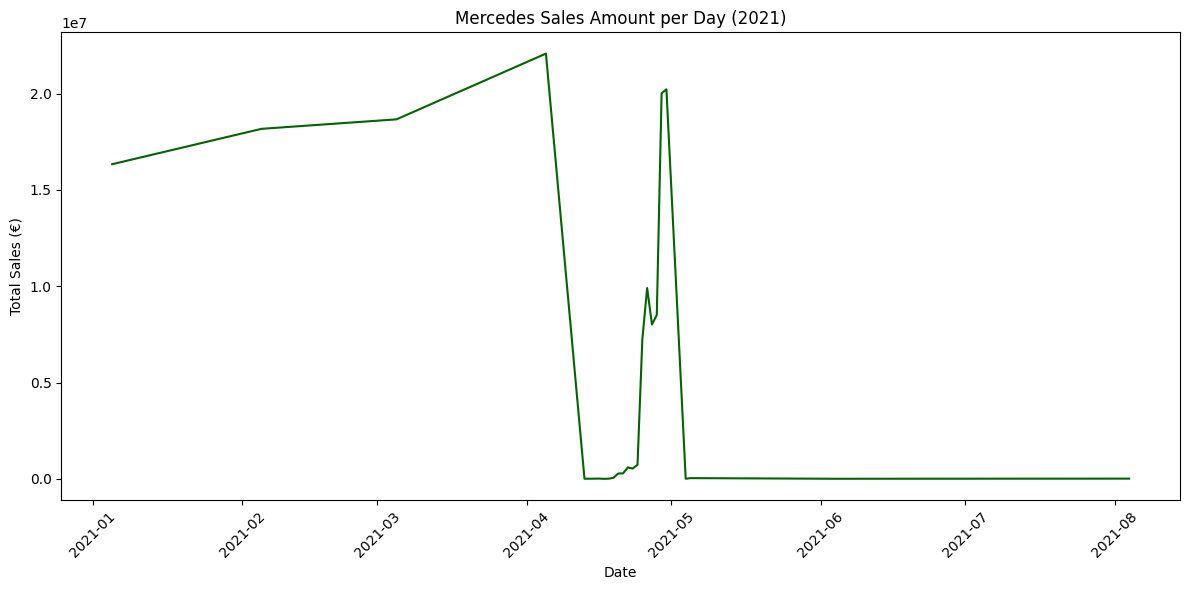

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure dates are in datetime format
Mercedes['Offer_publication_date'] = pd.to_datetime(Mercedes['Offer_publication_date'], errors='coerce')

# Filter for the year 2021
mercedes_2021 = Mercedes[
    (Mercedes['Offer_publication_date'].notna()) &
    (Mercedes['Offer_publication_date'].dt.year == 2021)
]

# Group by date and calculate total sales per day
sales_2021 = mercedes_2021.groupby('Offer_publication_date')['Price'].sum().reset_index()

# Plotting the total daily sales
plt.figure(figsize=(12, 6))
plt.plot(sales_2021['Offer_publication_date'], sales_2021['Price'], color='darkgreen')
plt.title('Mercedes Sales Amount per Day (2021)')
plt.xlabel('Date')
plt.ylabel('Total Sales (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


4) Pie chart of the Distribution of Vehicle Types for Mercedes-Benz Models

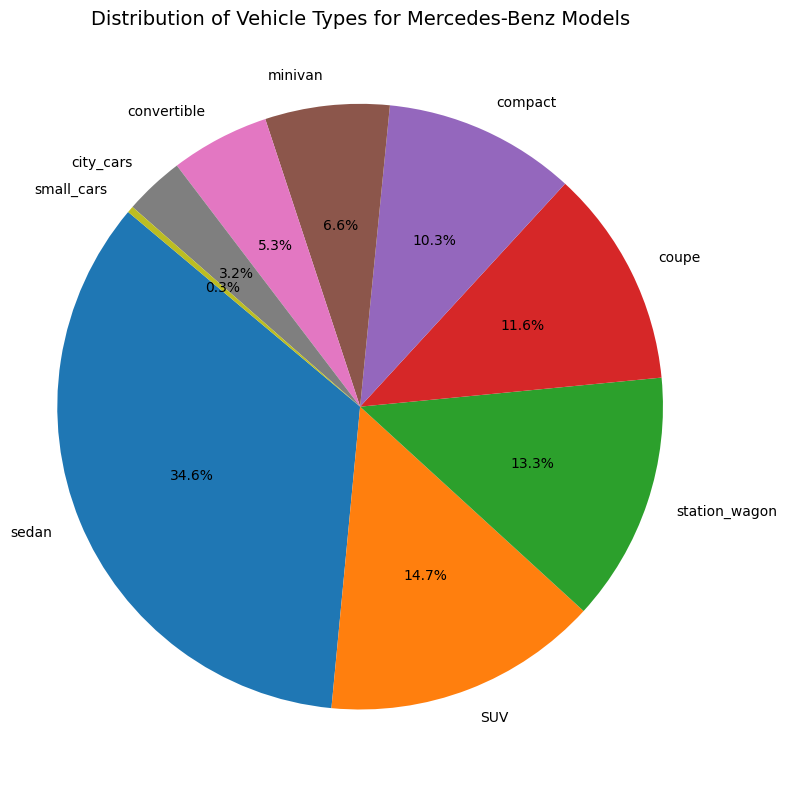

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Count the occurrences of each unique value in the 'Type' column
type_counts = Mercedes['Type'].value_counts()

# Calculate percentage
type_percentages = type_counts / type_counts.sum() * 100

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(type_percentages, labels=type_percentages.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Vehicle Types for Mercedes-Benz Models', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

